# SVM Sentiment Classifier — Stock Social Media Posts

Predicts sentiment class (`-1` = Bearish, `0` = Neutral, `1` = Bullish) from post text using TF-IDF + LinearSVC.

**Metrics reported per stock**: Accuracy, Confusion Matrix, Precision, Recall, F1 Score, MCC


In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    matthews_corrcoef,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── Configuration ─────────────────────────────────────────────
DATA_DIR = os.path.join("..", "pre-processing")   # path to _final.csv files
STOCKS = ["AAPL", "AMZN", "FB", "NVDA", "TSLA"]
SAMPLE_SIZE = 50000         # rows per stock (stratified)
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_TFIDF_FEATURES = 10_000
LABEL_MAP = {-1: "Bearish", 0: "Neutral", 1: "Bullish"}
LABEL_ORDER = [-1, 0, 1]
LABEL_NAMES = ["Bearish", "Neutral", "Bullish"]

## 1 — Load Data & Stratified Sampling

Each stock dataset is sampled to 50K rows (stratified by class) to keep SVM training fast while preserving class proportions.


In [3]:
# Load each _final.csv → clean → balanced sample (equal per class)
data = {}

for stock in STOCKS:
    path = os.path.join(DATA_DIR, f"{stock}_final.csv")
    print(f"Loading {stock} from {path} ...")
    df = pd.read_csv(path, low_memory=False)
    print(f"  Raw rows: {len(df):,}")
 
    # Balanced sample: equal number per class, capped by the smallest class
    class_counts = df["entities"].value_counts()
    min_class_size = class_counts.min()
    n_per_class = min(min_class_size, SAMPLE_SIZE // 3)  # at most SAMPLE_SIZE/3 per class

    sampled_parts = []
    for label, group in df.groupby("entities"):
        sampled_parts.append(group.sample(n=n_per_class, random_state=RANDOM_STATE))
    df = pd.concat(sampled_parts).reset_index(drop=True)

    print(f"  Sampled rows: {len(df):,}  ({n_per_class:,} per class)")
    print(f"  Class distribution:\n{df['entities'].value_counts().sort_index().to_string()}")
    print()

    data[stock] = df

print("All datasets loaded.")

Loading AAPL from ..\pre-processing\AAPL_final.csv ...
  Raw rows: 914,962
  Sampled rows: 49,998  (16,666 per class)
  Class distribution:
entities
-1    16666
 0    16666
 1    16666

Loading AMZN from ..\pre-processing\AMZN_final.csv ...
  Raw rows: 539,803
  Sampled rows: 49,998  (16,666 per class)
  Class distribution:
entities
-1    16666
 0    16666
 1    16666

Loading FB from ..\pre-processing\FB_final.csv ...
  Raw rows: 359,908
  Sampled rows: 49,998  (16,666 per class)
  Class distribution:
entities
-1    16666
 0    16666
 1    16666

Loading NVDA from ..\pre-processing\NVDA_final.csv ...
  Raw rows: 584,181
  Sampled rows: 49,998  (16,666 per class)
  Class distribution:
entities
-1    16666
 0    16666
 1    16666

Loading TSLA from ..\pre-processing\TSLA_final.csv ...
  Raw rows: 2,204,889
  Sampled rows: 49,998  (16,666 per class)
  Class distribution:
entities
-1    16666
 0    16666
 1    16666

All datasets loaded.


## 2 — TF-IDF Vectorization + Train/Test Split

We convert `body_no_stopwords` into TF-IDF features (unigrams + bigrams, top 10K features) and split 80/20 for each stock.


In [4]:
# Vectorize and split each stock
splits = {}  # stock → (X_train, X_test, y_train, y_test, vectorizer)

for stock in STOCKS:
    df = data[stock]
    print(f"Vectorizing {stock} ...")

    vectorizer = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES,
        ngram_range=(1, 2),
        sublinear_tf=True,        # dampens term-frequency with 1 + log(tf)
    )

    X = vectorizer.fit_transform(df["body_no_stopwords"])
    y = df["entities"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

    splits[stock] = (X_train, X_test, y_train, y_test, vectorizer)
    print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Features: {X_train.shape[1]:,}")

print("\nVectorization complete.")

Vectorizing AAPL ...
  Train: 39,998  |  Test: 10,000  |  Features: 10,000
Vectorizing AMZN ...
  Train: 39,998  |  Test: 10,000  |  Features: 10,000
Vectorizing FB ...
  Train: 39,998  |  Test: 10,000  |  Features: 10,000
Vectorizing NVDA ...
  Train: 39,998  |  Test: 10,000  |  Features: 10,000
Vectorizing TSLA ...
  Train: 39,998  |  Test: 10,000  |  Features: 10,000

Vectorization complete.


---

# Training

Drop all Neutral (0) rows and classify only Bullish (1) vs Bearish (-1). This removes the noisy majority class where many posts simply had no sentiment detected.


AAPL: 33,332 rows (Bearish=16,666, Bullish=16,666)
  Accuracy: 0.7266  |  F1(wtd): 0.7263  |  MCC: 0.4541
              precision    recall  f1-score   support

     Bearish       0.74      0.69      0.72      3334
     Bullish       0.71      0.76      0.74      3333

    accuracy                           0.73      6667
   macro avg       0.73      0.73      0.73      6667
weighted avg       0.73      0.73      0.73      6667


AMZN: 33,332 rows (Bearish=16,666, Bullish=16,666)
  Accuracy: 0.7231  |  F1(wtd): 0.7231  |  MCC: 0.4464
              precision    recall  f1-score   support

     Bearish       0.72      0.74      0.73      3334
     Bullish       0.73      0.71      0.72      3333

    accuracy                           0.72      6667
   macro avg       0.72      0.72      0.72      6667
weighted avg       0.72      0.72      0.72      6667


FB: 33,332 rows (Bearish=16,666, Bullish=16,666)
  Accuracy: 0.7497  |  F1(wtd): 0.7496  |  MCC: 0.4996
              precision    r

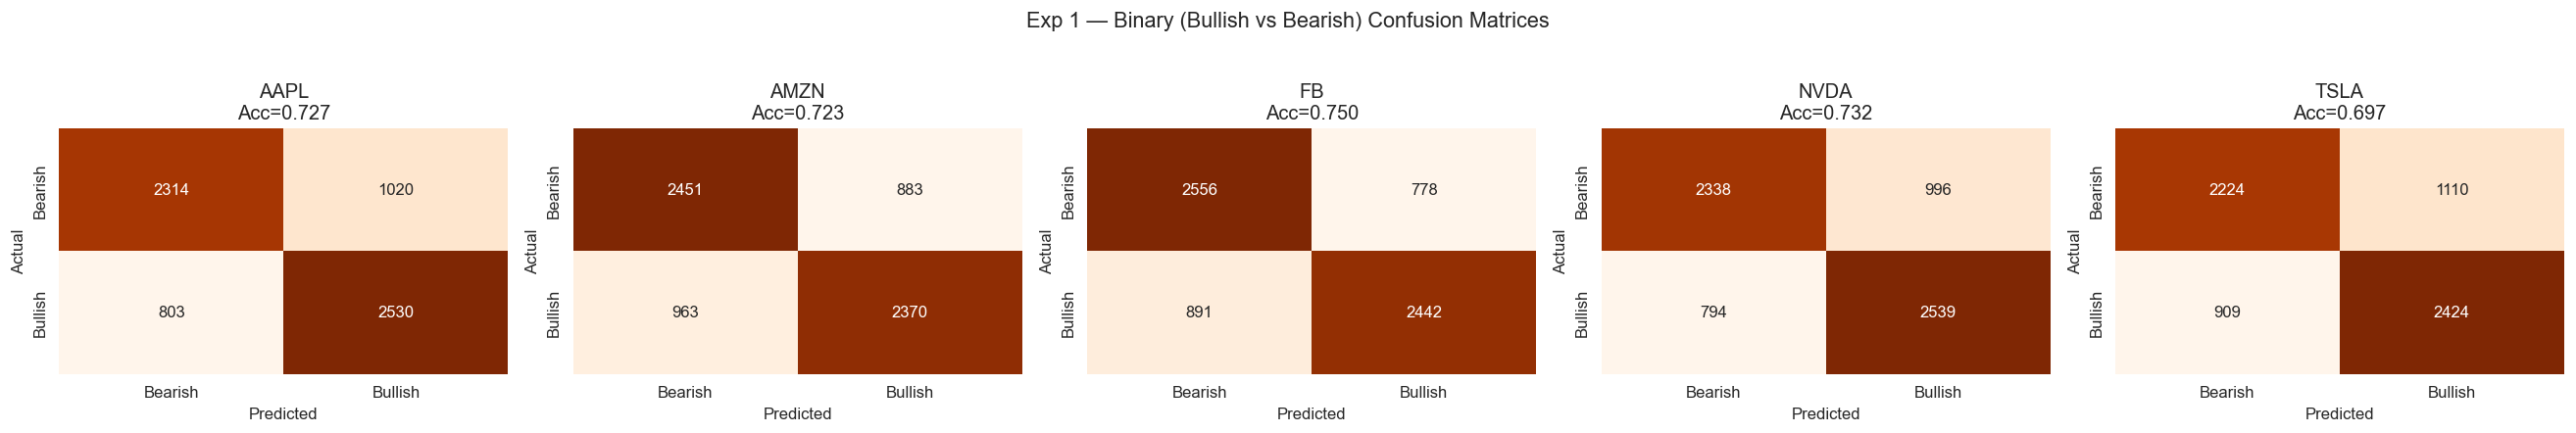

  3-Class vs Binary Comparison


,Binary Acc,Binary F1,Binary MCC
Stock,,,
AAPL,0.726564,0.726275,0.454096
AMZN,0.723114,0.723073,0.446354
FB,0.749663,0.749590,0.499610
NVDA,0.731513,0.731268,0.463884
TSLA,0.697165,0.696891,0.395055


In [10]:
# ── Experiment 1: Binary Classification (Bullish vs Bearish) ──────────
BINARY_LABELS = {-1: "Bearish", 1: "Bullish"}
BINARY_ORDER = [-1, 1]
BINARY_NAMES = ["Bearish", "Bullish"]

binary_results = {}

for stock in STOCKS:
    # Filter to only Bearish and Bullish
    df_bin = data[stock][data[stock]["entities"].isin([-1, 1])].copy()
    print(
        f"{stock}: {len(df_bin):,} rows (Bearish={sum(df_bin['entities']==-1):,}, Bullish={sum(df_bin['entities']==1):,})"
    )

    # TF-IDF
    vec_bin = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES, ngram_range=(1, 2), sublinear_tf=True
    )
    X_bin = vec_bin.fit_transform(df_bin["body_no_stopwords"])
    y_bin = df_bin["entities"].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bin, y_bin, test_size=TEST_SIZE, stratify=y_bin, random_state=RANDOM_STATE
    )

    # Train
    clf_bin = LinearSVC(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        dual=False,
    )
    clf_bin.fit(X_tr, y_tr)
    y_pr = clf_bin.predict(X_te)

    # Metrics
    acc = accuracy_score(y_te, y_pr)
    mcc = matthews_corrcoef(y_te, y_pr)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_te, y_pr, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_te, y_pr, labels=BINARY_ORDER)

    binary_results[stock] = {
        "accuracy": acc,
        "f1_weighted": f1_w,
        "mcc": mcc,
        "cm": cm,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "y_test": y_te,
        "y_pred": y_pr,
    }

    print(f"  Accuracy: {acc:.4f}  |  F1(wtd): {f1_w:.4f}  |  MCC: {mcc:.4f}")
    print(
        classification_report(
            y_te,
            y_pr,
            labels=BINARY_ORDER,
            target_names=BINARY_NAMES,
            zero_division=0,
        )
    )
    print()

# ── Confusion matrices ──
fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
fig.suptitle("Exp 1 — Binary (Bullish vs Bearish) Confusion Matrices", fontsize=13, y=1.04)
for ax, stock in zip(axes, STOCKS):
    cm = binary_results[stock]["cm"]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=BINARY_NAMES,
        yticklabels=BINARY_NAMES,
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"{stock}\nAcc={binary_results[stock]['accuracy']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("exp1_binary_cm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Comparison table ──
comp_rows = []
for stock in STOCKS:
    comp_rows.append(
        {
            "Stock": stock,
            "Binary Acc": binary_results[stock]["accuracy"],
            "Binary F1": binary_results[stock]["f1_weighted"],
            "Binary MCC": binary_results[stock]["mcc"],
        }
    )
comp_df = pd.DataFrame(comp_rows).set_index("Stock")
print("=" * 70)
print("  3-Class vs Binary Comparison")
print("=" * 70)
comp_df